[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anicka-net/nla-at-home/blob/main/notebooks/04_reading_between_the_lines.ipynb)

# 04 · Reading Between the Lines

### HAAISS workshop — core notebook 4 of 4

You can read a mind (NB1), inject by hand (NB2), and check faithfulness (NB3). This notebook is a toolbox of *ways to interrogate* an activation — each cell teaches one interpretability move you can reuse on any model.

Same setup as NB1 (Qwen 2.5 7B, T4). Run the setup cells, then any section in any order.

## Setup

In [1]:
!pip install -q -U transformers peft accelerate bitsandbytes matplotlib


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE       = "Qwen/Qwen2.5-7B-Instruct"          # the model whose mind we read
AV_ADAPTER = "anicka/nla-qwen2.5-7b-universal-av-grpo"    # the "verbalizer" (activation -> English)
LAYER      = 20                                   # chosen layer; the AV serves all 28
DEPTH_PCT  = 71                                   # nearest trained depth tag for layer 20
INJECT_CHAR  = "\u320e"                          # the placeholder token we overwrite: ㈎
INJECT_SCALE = 150.0                              # we normalize the activation's L2 norm TO this

/home/anicka/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "cuda"
assert torch.cuda.is_available(), "Runtime -> Change runtime type -> T4 GPU"

# 4-bit so a 7B model + adapters fit a free-Colab T4 (16 GB). fp16 compute:
# the GRPO-sharpened adapter is numerically sensitive, and fp16 on CUDA is a
# tested-safe path (bf16 on Apple MPS collapses it; not our case here).
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16)

tok  = AutoTokenizer.from_pretrained(BASE)
base = AutoModelForCausalLM.from_pretrained(BASE, quantization_config=bnb,
                                            device_map={"": 0})
model = PeftModel.from_pretrained(base, AV_ADAPTER).eval()   # adapter name = "default"

inject_id = tok.encode(INJECT_CHAR, add_special_tokens=False)
assert len(inject_id) == 1, f"injection char must be ONE token, got {inject_id}"
inject_id = inject_id[0]
print("loaded — base + AV adapter on", next(model.parameters()).device)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/339 [00:08<47:16,  8.39s/it]

Loading weights:   1%|          | 2/339 [00:16<46:34,  8.29s/it]

Loading weights:   1%|          | 4/339 [00:17<19:08,  3.43s/it]

Loading weights:   1%|▏         | 5/339 [00:18<14:57,  2.69s/it]

...

Loading weights:  97%|█████████▋| 330/339 [01:48<00:04,  2.24it/s]

Loading weights:  99%|█████████▊| 334/339 [01:48<00:01,  3.79it/s]

Loading weights:  99%|█████████▉| 336/339 [01:48<00:00,  4.48it/s]

Loading weights: 100%|██████████| 339/339 [01:48<00:00,  3.12it/s]

loaded — base + AV adapter on cuda:0


In [4]:
def get_layers(m):
    """Reach the transformer block list through the PEFT + CausalLM wrappers."""
    b = m.base_model.model if hasattr(m, "base_model") else m
    inner = b.model if hasattr(b, "model") else b
    return inner.layers

def read_activation(prompt, layer=LAYER, max_new_tokens=128):
    """Grab the clean base-model residual at the last prompt token."""
    chat = tok.apply_chat_template([{"role": "user", "content": prompt}],
                                   tokenize=False, add_generation_prompt=True)
    inp = tok(chat, return_tensors="pt").to(device)

    grab = {}
    def hook(mod, inpt, out):
        h = out[0] if isinstance(out, tuple) else out
        if "h" not in grab:                 # FIRST forward pass only — otherwise
            grab["h"] = h[:, -1, :].detach() # every generated token overwrites it
    handle = get_layers(model)[layer].register_forward_hook(hook)
    try:
        with model.disable_adapter(), torch.no_grad():
            out = model.generate(**inp, max_new_tokens=max_new_tokens, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
    finally:
        handle.remove()
    reply = tok.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True)
    return grab["h"].squeeze(0), reply

def normalize_to(v, scale=INJECT_SCALE):
    """Rescale v so its L2 norm equals `scale`. NOT v * scale — see notebook 02."""
    n = v.float().norm().clamp_min(1e-12)
    return v * (scale / n)

def av_prompt(depth_pct):
    return (
        "You are a meticulous AI researcher conducting an important investigation "
        "into activation vectors from a language model. Your overall task is to "
        "describe the semantic content of that activation vector.\n\n"
        "We will pass the vector enclosed in <concept> tags into your context, "
        "along with the network depth where it was extracted. "
        "You must then produce an explanation for the vector, enclosed within "
        "<explanation> tags. The explanation consists of 2-3 text snippets "
        "describing that vector.\n\n"
        f"Here is the vector from depth {depth_pct}% of the network:\n\n"
        f"<concept>{INJECT_CHAR}</concept>\n\n"
        "Please provide an explanation.\n\n"
        "<explanation>")

def describe(activation, depth=DEPTH_PCT, max_new_tokens=120, scale_fn=normalize_to):
    """The whole NLA read: build the prompt, overwrite the placeholder token's
    embedding with the (rescaled) activation, let the model narrate."""
    chat = tok.apply_chat_template([{"role": "user", "content": av_prompt(depth)}],
                                   tokenize=False, add_generation_prompt=True)
    ids = tok.encode(chat, add_special_tokens=False)  # match training: chat-wrapped, no BOS
    pos = ids.index(inject_id)
    input_ids = torch.tensor([ids], device=device)
    emb = model.get_input_embeddings()(input_ids).clone()
    emb[0, pos, :] = scale_fn(activation.to(emb.dtype))
    attn = torch.ones((1, len(ids)), device=device, dtype=torch.long)
    with torch.no_grad():
        out = model.generate(input_ids=input_ids, inputs_embeds=emb, attention_mask=attn,
                             max_new_tokens=max_new_tokens,
                             do_sample=False, pad_token_id=tok.eos_token_id)
    seq = out[0]
    gen = seq[len(ids):] if seq.shape[0] > len(ids) else seq  # embeds path returns new-only
    return tok.decode(gen, skip_special_tokens=True).split("</explanation>")[0].strip()

In [5]:
def grab_activation(prompt, layer=LAYER):
    """Forward-only (no generation) — fast, for building means/banks."""
    chat = tok.apply_chat_template([{"role": "user", "content": prompt}],
                                   tokenize=False, add_generation_prompt=True)
    inp = tok(chat, return_tensors="pt").to(device)
    grab = {}
    def hook(m, i, o):
        h = o[0] if isinstance(o, tuple) else o
        grab["h"] = h[:, -1, :].detach()
    hd = get_layers(model)[layer].register_forward_hook(hook)
    try:
        with model.disable_adapter(), torch.no_grad():
            model(**inp)
    finally:
        hd.remove()
    return grab["h"].squeeze(0)

def logit_lens(prompt, layer=LAYER, k=8):
    """The classic tool: project the layer-`layer` residual through the model's
    own final norm + unembedding to read it as vocabulary tokens."""
    chat = tok.apply_chat_template([{"role": "user", "content": prompt}],
                                   tokenize=False, add_generation_prompt=True)
    inp = tok(chat, return_tensors="pt").to(device)
    with model.disable_adapter(), torch.no_grad():
        out = model(**inp, output_hidden_states=True)
    h = out.hidden_states[layer + 1][0, -1]
    base = model.base_model.model if hasattr(model, "base_model") else model
    inner = base.model if hasattr(base, "model") else base
    logits = model.get_output_embeddings()(inner.norm(h))
    return [tok.decode([t]) for t in logits.topk(k).indices.tolist()]

## A · Center for comparison; read the full activation

Subtracting an average can expose distinctions for **geometric comparisons**, but the centered vector is not itself a residual state from the model. The NLA was trained on full activations, so describe the full state and reserve the deviation for cosine or projection calculations.

In [6]:
# build a "generic" mean over a handful of unrelated prompts
bank_prompts = ["What is 2+2?", "Describe a sunset.", "Write a for loop.",
                "Who was Napoleon?", "How do plants grow?", "Translate hi to French.",
                "What is a black hole?", "Give me a pasta recipe."]
mean_act = torch.stack([grab_activation(p) for p in bank_prompts]).mean(0)

target = "SELECT name, email FROM users WHERE active = true;"
act = grab_activation(target)
deviation = act - mean_act

print("FULL activation readout:\n ", describe(act))
print(f"\n|activation|={act.norm():.1f}  |activation-mean|={deviation.norm():.1f}")
print("The centered vector is used below for geometry, not injected into the NLA.")

/home/anicka/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


FULL activation readout:
  - SQL query: SELECT * FROM customers WHERE age > 30; with `customers` as table name and `age > 30` as filter condition
- Intent classification: database-query or code-execution frame
- Response strategy: explanatory or clarifying (e.g., "This query selects all customers older than 30")
- Tension between "explain this query" and "what does this do?" due to lack of context about the query's purpose
- Output format: likely a short declarative sentence rather than a code block, given the interrogative structure of the

|activation|=123.0  |activation-mean|=73.0
The centered vector is used below for geometry, not injected into the NLA.


## B · Compare a contrast without injecting the difference

A minimal-pair difference is usually tiny. Normalizing that bare difference to the NLA's injection norm amplifies noise and leaves the training distribution. Instead, interpolate between the two full states. The endpoints are real activations; if their captions do not separate, the decoder cannot resolve this contrast and interpolation cannot rescue it.


In [7]:
pairs = [("The cat sat on the mat.", "The dog sat on the mat."),
         ("The capital of France is Paris.", "The capital of Japan is Tokyo."),
         ("I am so happy today!", "I am so sad today!")]

for a_txt, b_txt in pairs:
    a, b = grab_activation(a_txt), grab_activation(b_txt)
    d = a - b
    print(f"[{b_txt!r}]  ->  [{a_txt!r}]")
    print(f"   |state|≈{(a.norm() + b.norm()) / 2:.0f}  |difference|={d.norm():.0f}")
    for lam in [0.0, 0.5, 1.0]:
        state = b + lam * d
        print(f"   mix={lam:.1f}:", describe(state)[:220])
    print()


['The dog sat on the mat.']  ->  ['The cat sat on the mat.']
   |state|≈110  |difference|=14


   mix=0.0: - Simple declarative sentence: "The cat sat on the mat."
- Subject-verb-object structure: "cat" (subject), "sat" (verb), "mat" (object)
- Predicted next token: period or follow-up clause ("and")
- Contextual frame: domes


   mix=0.5: - Simple declarative sentence: "A man is holding a book"
- Subject-verb-object structure: "The book has a dog on its back"
- Syntactic role: "and" as conjunction
- Predicted next token: period or continuation clause
- Co


   mix=1.0: - Simple declarative sentence: "A man walked into a bar and said" (with "and" as a conjunction)
- Canonical three-token sequence: "The man said" (with "the man" as a subject and "said" as a predicate)
- Response strategy



['The capital of Japan is Tokyo.']  ->  ['The capital of France is Paris.']
   |state|≈126  |difference|=13


...

   mix=1.0: - Geopolitical fact-checking: "The capital of Australia is Canberra" and "Canberra is the capital of Australia" as affirmative confirmation
- Binary question frame: "Is this statement correct?" with a yes/no judgment res



['I am so sad today!']  ->  ['I am so happy today!']
   |state|≈132  |difference|=74


   mix=0.0: - Emotional-distress and social-interaction frames: "I feel so sad" and "you're not talking to me"
- Empathetic validation response strategy: "i feel so sad sometimes"
- Tone calibration: "not feeling okay" and "lonely" 


   mix=0.5: - Emotional state: "I feel so happy" as positive valence
- Social register: "you're doing great today" as supportive affirmation
- Response strategy: empathetic acknowledgment ("That sounds amazing") rather than correcti


   mix=1.0: - Positive sentiment: "I'm so happy" and "you did something great"
- Emotional valence: "happy" and "great"
- Response strategy: warm affirmation and social engagement
- Tone: casual and enthusiastic ("Wow")
- Context: n



## C · "The model processes this *like* it processes ___" (nearest neighbour)

Interpretation by analogy: center each activation against the generic mean, then find the stored example with the closest **deviation**. Raw residual cosine is dominated by structure shared across prompts.

In [8]:
import torch.nn.functional as F
library = ["def quicksort(items): return sorted(items)",
           "Write a sad poem about winter rain.",
           "Review this legal contract clause.",
           "Balance this chemistry equation: H2 + O2 -> H2O.",
           "Draft an angry customer complaint email.",
           "Give me a recipe for tomato soup.",
           "Prove that the square root of two is irrational.",
           "Write a love letter."]
lib_acts = torch.stack([grab_activation(x) for x in library])

query = "def merge_sort(arr): return arr if len(arr)<2 else merge(...)"
q = grab_activation(query)
center = mean_act.float().cpu()
q_centered = q.float().cpu() - center
lib_centered = lib_acts.float().cpu() - center
sims = F.cosine_similarity(q_centered.unsqueeze(0), lib_centered)
best = sims.argmax().item()
print(f"query: {query!r}")
print(f"nearest centered activation: {library[best]!r}  (cos {sims[best]:.2f})")
print("query readout    :", describe(q))
print("neighbour readout:", describe(lib_acts[best]))

query: 'def merge_sort(arr): return arr if len(arr)<2 else merge(...)'
nearest centered activation: 'def quicksort(items): return sorted(items)'  (cos 0.69)


query readout    : - `math.ceil` and `n**2` are part of a Python function body: `def sqrt(n):`
- `while True:` loop structure with `n - math.ceil(math.sqrt(n)) ** 2` as decrementing condition
- `return i` as final return statement
- `i` is likely an iteration index or accumulator
- `+` at the end of the snippet signals an incomplete code block, predicting a closing brace or comment
- The model is classifying this as a missing terminal case or boundary check, with `math.ceil(math.sqrt(n))


neighbour readout: - Code-evaluation frame: "This code is a simple implementation of a function" and "but it's not efficient because it uses a loop"
- Predicted response: critique of `for` loop and `range(n**2)` as inefficient
- Competing interpretation: "use built-in functions like `sum()` or `*` operator" as alternative to manual multiplication
- Tone: neutral technical assessment rather than instructional
- Response strategy: acknowledge simplicity, point out inefficiency, suggest improvement using `numpy`, `math.prod`, or list comprehension
- Output structure: likely "The


## D · NLA vs the logit lens (two interpretability tools, side by side)

The **logit lens** reads a hidden state by projecting it through the model's own output vocabulary — it gives you *tokens*. The **NLA** gives you a *description*. Same activation, two windows. Watch where tokens are cryptic and the sentence is legible (and vice versa).

In [9]:
for p in ["Explain how a hash map handles collisions.",
          "The capital of Australia is",
          "Write a haiku about rain."]:
    act = grab_activation(p)
    print(f":: {p!r}")
    print("   logit lens (tokens) :", logit_lens(p))
    print("   NLA (description)   :", describe(act))
    print()

:: 'Explain how a hash map handles collisions.'


   logit lens (tokens) : ['换句话', ' misog', ' pregn', '从根本', '在一个', '总而言之', ' fick', ' The']


   NLA (description)   : - Hash table: data structure for key-value storage
- "how does hash table works" frame: mechanism-explanation response
- "in terms of hashing algorithm" constraint: technical precision (hashing function, collision resolution)
- "in computer science" context: formal, neutral register
- Response strategy: step-by-step procedural explanation (hashing, storing, retrieving keys and values) with a focus on collision handling (chaining or probing)

:: 'The capital of Australia is'


   logit lens (tokens) : ['换句话', '性价', ' anál', ' The', ' misog', ' blat', '没错', '视听节目']


   NLA (description)   : - Capital city of Australia: Canberra
- Geographic and geopolitical knowledge retrieval: "The capital of Australia" as factual location query
- Direct declarative answer: "Canberra" as primary response token
- Contextual constraint: "What is the capital of Australia?" as simple factual question
- Response strategy: short, confident, direct answer without hedging or elaboration
- Tension between "capital" and "Australia": model must resolve to Canberra, suppressing alternative interpretations like Sydney or Melbourne.

:: 'Write a haiku about rain.'


   logit lens (tokens) : ['性价', ',");\n', '瞟', '取决', '但不限', ' sluts', '_ISR', 'こともあります']


   NLA (description)   : - Poetic generation task: "Write a short poem starting with rain falls vertically down"
- Imagery and sensory tokens ("wet asphalt", "cherry blossom") as constraints
- Line-break and meter patterns favored over prose
- Tension between literal verticality and metaphorical stillness, with "poem" and "spring evening" favoring metaphorical stillness
- Response strategy: opening line with "rain falls" followed by a volta or stasis, using "cherry blossoms" as a visual anchor
- Tone: lyrical and evocative, with a



## E · Does it ever just make things up? (negative controls)

The essential skeptic's check. If the readout is *content-specific*, then feeding it nonsense should visibly change or degrade it. Two controls: pure **noise**, and an activation from the **wrong layer** described as if it came from depth 71%. A readout that stays confident on noise is confabulating — the SpongeBob lesson, live.

In [10]:
real = grab_activation("Explain how photosynthesis works.")
noise = torch.randn_like(real)                 # pure Gaussian noise
wrong_layer = grab_activation("Explain how photosynthesis works.", layer=5)

print("REAL  (L20):", describe(real))
print("NOISE      :", describe(noise), "   <- if this is confident + specific, it is confabulating")
print("WRONG LAYER (L5 described as 71%):", describe(wrong_layer))

REAL  (L20): - Scientific-explanatory response: "How does photosynthesis work?" with "photosynthesis" as the subject and "work" as the mechanism-query frame.
- Output strategy: step-by-step procedural explanation (e.g., "Photosynthesis begins with...") rather than definition or list.
- Contextual constraints: "explain" and "step by step" favoring a sequential, causal structure.
- Tension between breadth ("how does it work") and depth ("step by step"), with the model likely focusing on the broad overview first before diving into specific stages like chlorophyll absorption, electron


NOISE      : - **Code-generation task**: "Write python code to predict safe spots" with `predict safe spots` as the primary output constraint.
- **Data structure**: `safe_spots = [[0, 1], [1, 4], [2, 5], [3, 6], [4, 7], [5, 8], [6, 9]]` as a list of integer pairs representing safe cell indices.
- **Machine-learning pipeline**: `import numpy as np`, `from sklearn.model_selection import train_test_split`, and `def predict_safe_spots    <- if this is confident + specific, it is confabulating


WRONG LAYER (L5 described as 71%): - Physics-explanation request: "How does [X] work?" with "explain how [X] works" as a direct question frame.
- Response strategy: mechanistic, step-by-step explanation of the physical processes involved in hair dyeing.
- Topic classification: chemistry and cosmetics, with "hair dye" as the subject.
- Key concepts: pigments, chemical reactions, melanin interaction, and pH-dependent color changes.
- Tension between "how it works" (mechanism) and "chemical processes" (specific reactions), with the latter likely dominating due to the specificity of


## F · Why preprocessing *is* interpretability (the massive-activation trap)

This cell needs no GPU — it's real measured data. Qwen spreads activation energy across dimensions; this Gemma run puts **97% into one dimension**. That spike makes pairwise cosine nearly constant and can dominate PCA or whole-vector normalization. It is one major confound in our old small-Gemma failure, alongside contaminated training descriptions; the clean sink-corrected retry is a separate experiment. The lesson is to inspect geometry before reusing an injection recipe across model families.

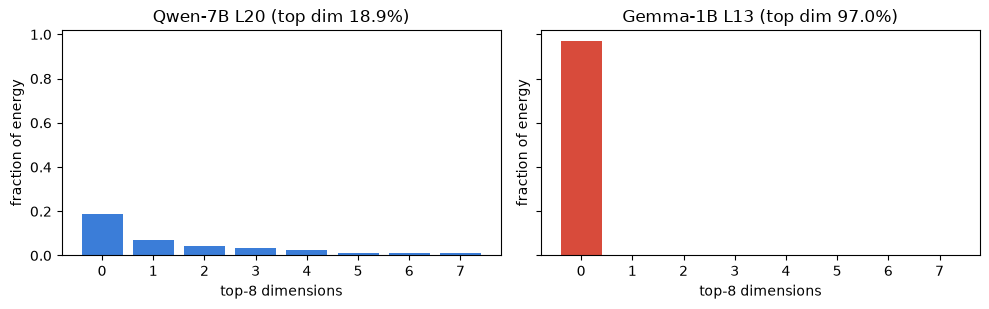

Qwen: energy spread across many dims -> cosine/normalize geometry works.
Gemma: one dim eats everything -> must center / drop-top-PC before reading.


In [11]:
import matplotlib.pyplot as plt
# real measured top-8 per-dimension energy fractions (this repo, 2026-07)
QWEN_L20  = [0.189, 0.072, 0.045, 0.035, 0.023, 0.013, 0.011, 0.010]
GEMMA_L13 = [0.970, 0.002, 0.001, 0.001, 0.0005, 0.0005, 0.0004, 0.0004]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
ax[0].bar(range(8), QWEN_L20, color="#3b7dd8");  ax[0].set_title("Qwen-7B L20 (top dim 18.9%)")
ax[1].bar(range(8), GEMMA_L13, color="#d84b3b"); ax[1].set_title("Gemma-1B L13 (top dim 97.0%)")
for a in ax: a.set_xlabel("top-8 dimensions"); a.set_ylabel("fraction of energy")
plt.tight_layout(); plt.show()
print("Qwen: energy spread across many dims -> cosine/normalize geometry works.")
print("Gemma: one dim eats everything -> must center / drop-top-PC before reading.")

## G · Triangulate against Anthropic's NLA (extension)

Two independently trained NLAs describing the same activation provide useful triangulation: agreement raises confidence, while disagreement exposes decoder dependence. It is not proof, because both readers share the same Qwen base and may share its priors. Anthropic's `kitft/nla-qwen2.5-7b-L20-av` is a **full model** (not a LoRA), so compare precomputed readouts and keep each checkpoint's own injection and prompt interface.

---
### ✅ Self-check
Section **F runs with no GPU** and must always show the two bar charts (Qwen spread, Gemma one spike). For the GPU sections, the sign of success is *differential*: the deviation/difference/wrong-layer readouts should read **differently** from the plain one, and NOISE should look visibly less grounded. If every cell returns the same text, injection isn't landing — back to NB2.

In [12]:
QWEN_L20  = [0.189, 0.072, 0.045, 0.035, 0.023, 0.013, 0.011, 0.010]
assert QWEN_L20[0] < 0.5 and 0.97 > 0.5, "energy-concentration data sanity"
print("self-check: Qwen top-dim", f"{QWEN_L20[0]:.0%}", "vs Gemma 97% — "
      "the contrast that explains the small-model failure \u2713")

self-check: Qwen top-dim 19% vs Gemma 97% — the contrast that explains the small-model failure ✓
